|     |                     |
|----------------|-------------------------------|
|  Tugas Proyek   |  Aljabar Linear                |
| Nama           | Kevin Synagogue Panjaitan     |
| NIM            | F1C221058                     |


In [3]:
import numpy as np
import sympy as sy
sy.init_printing() 

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [4]:
np.set_printoptions(precision=3)
np.set_printoptions(suppress=True)

In [5]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" 

In [6]:
def round_expr(expr, num_digits):
    return expr.xreplace({n : round(n, num_digits) for n in expr.atoms(sy.Number)})

# <font face="gotham" color="purple"> Operasi Matriks</font>

Operasi _penjumlahan_ matriks cukup sederhana:
1. $A + B = B + A$
2. $(A + B) + C = A + (B + C)$
3. $c(A + B) = cA + cB$
4. $(c + d)A = cA + dA$
5. $c(dA) = (cd)A$
6. $A + 0 = A$, di mana $0$ adalah matriks nol
7. Untuk setiap $A$, terdapat $-A$ sehingga $A + (-A) = 0$.

Semuanya sudah jelas sebagaimana terlihat, jadi tidak diberikan pembuktiannya.  
Sifat-sifat dari _perkalian_ matriks adalah:
1. $A(BC) = (AB)C$
2. $c(AB) = (cA)B = A(cB)$
3. $A(B + C) = AB + AC$
4. $(B + C)A = BA + CA$


Perlu diperhatikan bahwa kita harus membedakan antara dua jenis perkalian:  
_perkalian Hadamard_, yang dinotasikan sebagai $A \odot B$ (perkalian elemen demi elemen), dan _perkalian matriks_, yang dinotasikan cukup dengan $AB$.


In [7]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

In [8]:
A*B # Ini adalah perkalian elemen demi elemen


array([[ 5, 12],
       [21, 32]])

In [9]:
A@B # Ini adalah perkalian matriks


array([[19, 22],
       [43, 50]])

Mari kita tunjukkan secara eksplisit aturan perkalian matriks untuk setiap elemennya:


In [10]:
np.sum(A[0,:]*B[:,0]) # element at (1, 1)
np.sum(A[1,:]*B[:,0]) # element at (2, 1)
np.sum(A[0,:]*B[:,1]) # element at (1, 2)
np.sum(A[1,:]*B[:,1]) # element at (2, 2)

19

43

22

50

## <font face="gotham" color="purple"> Demonstrasi SymPy: Penjumlahan </font>


Mari kita definisikan semua huruf sebagai simbol untuk berjaga-jaga jika kita perlu menggunakannya berulang kali.  
Dengan pustaka ini, kita dapat melakukan perhitungan secara analitik, menjadikannya alat yang berharga untuk mempelajari aljabar linear.
Mari kita definisikan semua huruf sebagai simbol untuk berjaga-jaga jika kita perlu menggunakannya berulang kali.  
Dengan pustaka ini, kita dapat melakukan perhitungan secara analitik, menjadikannya alat yang berharga untuk mempelajari aljabar linear.


In [11]:
a, b, c, d, e, f, g, h, i, j, k, l, m, n, o, p, q, r, s, t, u, v, w, x, y, z = sy.symbols('a, b, c, d, e, f, g, h, i, j, k, l, m, n, o, p, q, r, s, t, u, v, w, x, y, z', real = True)

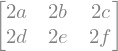

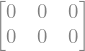

In [12]:
A = sy.Matrix([[a, b, c], [d, e, f]])
A + A
A - A

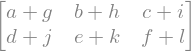

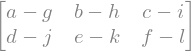

In [13]:
B = sy.Matrix([[g, h, i], [j, k, l]])
A + B
A - B

## <font face="gotham" color="purple"> Demonstrasi SymPy: Perkalian </font>


Aturan perkalian matriks dapat dipahami dengan jelas dengan menggunakan simbol-simbol.


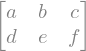

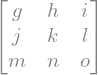

In [14]:
A = sy.Matrix([[a, b, c], [d, e, f]])
B = sy.Matrix([[g, h, i], [j, k, l], [m, n, o]])
A
B

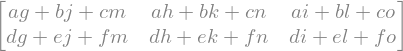

In [15]:
AB = A*B; AB

## <font face="gotham" color="purple"> Sifat Komutatif pada Matriks </font>


Perkalian matriks biasanya tidak bersifat komutatif, yang berarti ${AB} \neq {BA}$.  
Sebagai contoh, perhatikan matriks $A$ dan $B$ berikut:


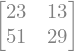

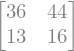

In [16]:
A = sy.Matrix([[3, 4], [7, 8]])
B = sy.Matrix([[5, 3], [2, 1]])
A*B
B*A

Bagaimana cara menemukan matriks yang komutatif? Mari kita coba mencari secara analitik.


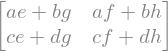

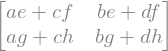

In [17]:
A = sy.Matrix([[a, b], [c, d]])
B = sy.Matrix([[e, f], [g, h]])
A*B
B*A

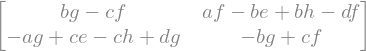

In [18]:
M = A*B - B*A; M

Diberikan Sebuah Sistem Persamaan Linear 
$$
\begin{align}
b g - c f&=0 \\
 a f - b e + b h - d f&=0\\
- a g + c e - c h + d g&=0 \\
- b g + c f&=0
\end{align}
$$

Untuk menyelesaikannya, kita dapat menggunakan metode eliminasi Gauss–Jordan.  
Jika kita menganggap $a, b, c, d$ sebagai koefisien sistem, maka kita dapat membentuk matriks augmentasi sebagai berikut:

$$
\begin{align*}
b g - c f = 0 \quad &\Rightarrow -c f + b g + 0 e + 0 h = 0\\
a f - b e + b h - d f = 0 \quad &\Rightarrow (a - d) f + 0 g - b e + b h = 0\\
- a g + c e - c h + d g = 0 \quad &\Rightarrow 0 f + (d - a) g + c e - c h = 0\\
- b g + c f = 0 \quad &\Rightarrow c f - b g + 0 e + 0 h = 0
\end{align*}
$$

Sehingga matriks augmentasinya berbentuk:

$$
\begin{equation}
\left[\begin{array}{cccc:c}
-c & b & 0 & 0 & 0 \\
a-d & 0 & -b & b & 0 \\
0 & d-a & c & -c & 0 \\
c & -b & 0 & 0 & 0
\end{array}\right]
\end{equation}
$$


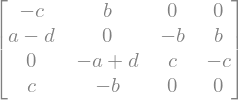

In [19]:
A_aug = sy.Matrix([[-c, b, 0, 0], [a-d,0, -b, b], [0, d-a, c, -c], [c, -b, 0, 0]]); A_aug

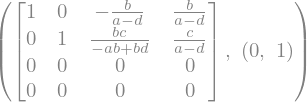

In [20]:
A_aug.rref()

Maka Solusi Umumnya
$$
\begin{equation}
\left(\begin{array}{l}
e \\
f \\
g \\
h
\end{array}\right)=c_1\left(\begin{array}{c}
\frac{b}{a-d} \\
\frac{b c}{a b-b d} \\
1 \\
0
\end{array}\right)+c_2\left(\begin{array}{c}
-\frac{b}{a-d} \\
-\frac{c}{a-d} \\
0 \\
1
\end{array}\right)
\end{equation}
$$

In [49]:
import sympy as sp

# definisikan Matrix  A (2x2 matriks)
a, b, c, d = sp.symbols('a b c d')

# definisikan Matrix  B (2x2 matriks)
e, f, g, h = sp.symbols('e f g h')

# definisikan Matrix A dan  B (2x2 matriks)
A = sp.Matrix([[a, b], [c, d]])
B = sp.Matrix([[e, f], [g, h]])

# hitung  AB dan  BA
AB = A * B
BA = B * A

# Set Persamaan Menjadi  AB = BA
equations = [
    sp.Eq(AB[i, j], BA[i, j]) for i in range(2) for j in range(2)
]

# Penyelesaian Persamaan 
solution = sp.solve(equations, (e, f, g, h))

# Menampilkan Solusi Umumnya 
print("Solution for B elements:")
for sol in solution:
    print(f"{sol}: {solution[sol]}")

# Untuk menuliskan solusi dalam bentuk terparameter, mari kita substitusikan nilai-nilai tertentu
# Definisikan parameter c1 dan c2
c1, c2 = sp.symbols('c1 c2')

# Definisikan solusi terparameter
parametric_solution = {
    e: solution[e].subs({g: c1, h: c2}),
    f: solution[f].subs({g: c1, h: c2}),
    g: c1,
    h: c2
}

# Cetak solusi terparameter dalam format LaTeX
print("\nSolusi terparameter dalam format LaTeX:")
for sol in parametric_solution:
    print(f"{sp.latex(sol)}: {sp.latex(parametric_solution[sol])}")



Solution for B elements:
e: h + g*(a - d)/c
f: b*g/c

Solusi terparameter dalam format LaTeX:
e: c_{2} + \frac{c_{1} \left(a - d\right)}{c}
f: \frac{b c_{1}}{c}
g: c_{1}
h: c_{2}


$$
e: c_{2} + \frac{c_{1} \left(a - d\right)}{c}\\
f: \frac{b c_{1}}{c}\\
g: c_{1}\\
h: c_{2}\\
$$

# <font face="gotham" color="purple"> Matriks Transpose </font>

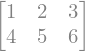

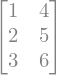

In [22]:
A = sy.Matrix([[1, 2, 3], [4, 5, 6]]); A
A.transpose()

Sifat-sifat transpose adalah:
1. $(A^T)^T = A$
2. $(A + B)^T = A^T + B^T$
3. $(cA)^T = cA^T$
4. $(AB)^T = B^T A^T$

Kita dapat menunjukkan mengapa sifat terakhir berlaku menggunakan SymPy:  
definisikan $A$ dan $B$, kalikan keduanya, lalu ambil transpose-nya, yaitu $(AB)^T$.


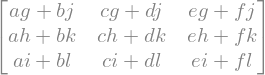

In [23]:
A = sy.Matrix([[a, b], [c, d], [e, f]])
B = sy.Matrix([[g, h, i], [j, k, l]])
AB = A*B
AB_t = AB.transpose(); AB_t

Transpose $A$ and $B$, then multiply, meaning $B^TA^T$

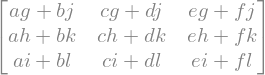

In [24]:
B_t_A_t = B.transpose()*A.transpose()
B_t_A_t

Check if they are equal

In [25]:
AB_t == B_t_A_t

True

# <font face="gotham" color="purple"> Indentifikasi matirks </font>

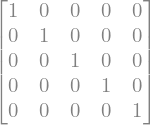

In [26]:
sy.eye(5)

Identity matrix properties:

$$
AI=IA = A
$$

Mari kita hasilkan $I$ dan $A$, lalu tunjukkan apakah hal tersebut berlaku


In [27]:
I = np.eye(5); I

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]])

In [28]:
A = np.around(np.random.rand(5, 5)*100); A # generate a random matrix

array([[40., 61., 76., 53., 45.],
       [50., 96., 97., 64., 73.],
       [43., 99., 77.,  9., 68.],
       [90., 59., 39., 71., 17.],
       [70., 27., 89., 27., 50.]])

Check if they are equal

In [29]:
(A@I == I@A).all()

True

# <font face="gotham" color="purple"> Matriks Elementer </font>


Sebuah _matriks elementer_ adalah matriks yang dapat diperoleh dari satu operasi baris elementer pada matriks identitas. Contohnya:


Menukar baris $R_1$ dan $R_2$ menghasilkan matriks berikut:

$$
\left[
\begin{array}{ccc}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{array}
\right]
\begin{array}{c}
R_1 \leftrightarrow R_2 \\
~ \\
~
\end{array}
\qquad \Longrightarrow \qquad
\left[
\begin{array}{ccc}
0 & 1 & 0 \\
1 & 0 & 0 \\
0 & 0 & 1
\end{array}
\right]
$$


Di mana $R_1 \leftrightarrow R_2$ berarti menukar baris 1 dan baris 2, kita nyatakan matriks yang telah diubah tersebut sebagai $E$. Kemudian, mengalikan $E$ di sebelah kiri matriks $A$ akan melakukan operasi baris yang sama persis.  

Pertama, hasilkan matriks $A$.


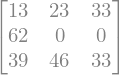

In [30]:
A = sy.randMatrix(3, percent = 80); A # generate a random matrix with 80% of entries being nonzero

Buat sebuah matriks elementer dengan $R_1 \leftrightarrow R_2$


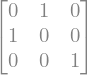

In [31]:
E = sy.Matrix([[0, 1, 0], [1, 0, 0], [0, 0, 1]]);E

Perhatikan bahwa dengan mengalikan $E$ di sebelah kiri matriks $A$, matriks $A$ juga menukar baris 1 dan baris 2.


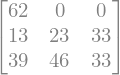

In [32]:
E*A

Menambahkan kelipatan suatu baris ke baris lain pada matriks identitas juga menghasilkan matriks elementer.

$$
\begin{align}
\left[
\begin{array}{ccc}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{array}
\right]
&\xrightarrow{R_3 - 7R_1}
\left[
\begin{array}{ccc}
1 & 0 & 0 \\
0 & 1 & 0 \\
-7 & 0 & 1
\end{array}
\right]
\end{align}
$$

Mari kita verifikasi dengan SymPy.
.

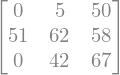

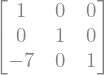

In [33]:
A = sy.randMatrix(3, percent = 80); A
E = sy.Matrix([[1, 0, 0], [0, 1, 0], [-7, 0, 1]]); E

Kita akan melihat bahwa operasi $R_3 - 7R_1$ terjadi pada matriks $A$


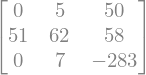

In [34]:
E*A

Kita juga dapat mereproduksinya melalui operasi baris secara eksplisit pada $A$.


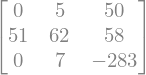

In [35]:
EA = sy.matrices.MatrixBase.copy(A)
EA[2,:]=-7*EA[0,:]+EA[2,:]
EA

Pada bagian selanjutnya, kita akan meninjau kembali sebuah kesimpulan penting:  
sebuah _matriks yang dapat dibalik (invertible)_ merupakan hasil perkalian dari serangkaian matriks elementer.


# <font face="gotham" color="purple"> Invers MAtriks </font>

Jika ${AB} = {BA} = \mathbf{I}$, maka $B$ disebut sebagai invers dari matriks $A$, yang dinotasikan sebagai $B = A^{-1}$.



NumPy memiliki fungsi praktis ```np.linalg.inv()``` untuk menghitung invers matriks.  
Sekarang, buat matriks $A$.


In [36]:
A = np.round(10*np.random.randn(5,5)); A

array([[-12., -15.,  16.,  -0.,   4.],
       [ -7.,   2.,   9.,  -0., -21.],
       [ 18.,   9.,  -5., -15.,   1.],
       [ -4.,  10., -17.,  -4., -18.],
       [ -3.,  16.,  -5.,   2.,   2.]])

In [37]:
Ainv = np.linalg.inv(A); Ainv

array([[-0.063,  0.018,  0.005, -0.04 , -0.04 ],
       [-0.003,  0.018,  0.012, -0.014,  0.06 ],
       [ 0.007,  0.039,  0.014, -0.042,  0.019],
       [-0.078,  0.017, -0.058, -0.043, -0.016],
       [ 0.024, -0.035,  0.005, -0.006,  0.027]])

Periksa apakah mereka benar-benar invers satu sama lain


In [38]:
A@Ainv

array([[ 1., -0.,  0.,  0., -0.],
       [ 0.,  1.,  0.,  0., -0.],
       [ 0., -0.,  1., -0.,  0.],
       [ 0.,  0., -0.,  1.,  0.],
       [ 0.,  0., -0.,  0.,  1.]])

The ```-0.``` means there are more digits after point, but omitted here.

## <font face="gotham" color="purple"> Metode Eliminasi Gauss–Jordan untuk Invers Matriks </font>


Cara yang praktis untuk menghitung invers dari suatu matriks adalah dengan membentuk matriks augmentasi $[A \,|\, \mathbf{I}]$.  
Kemudian, kalikan dengan serangkaian matriks elementer $E$ (yang mewakili operasi baris elementer) hingga matriks $A$ berada dalam bentuk baris tereduksi.  
Jika $A$ memiliki peringkat penuh (full rank), proses ini akan mengubah $A$ menjadi matriks identitas $\mathbf{I}$.  
Akibatnya, matriks identitas di sisi kanan matriks augmentasi tersebut akan otomatis berubah menjadi $A^{-1}$.

Kita dapat mendemonstrasikan hal ini menggunakan fungsi `.rref()` dari SymPy pada matriks augmentasi $[A \,|\, \mathbf{I}]$.


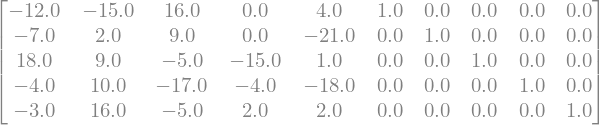

In [39]:
AI = np.hstack((A, I)) # stack the matrix A and I horizontally
AI = sy.Matrix(AI); AI

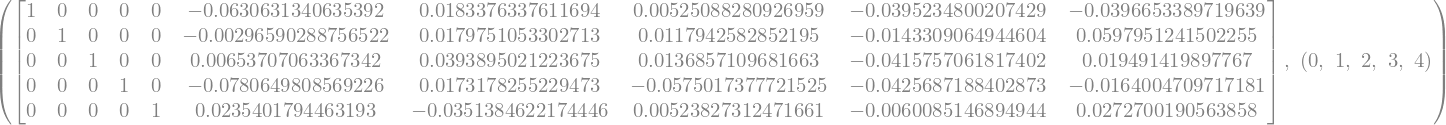

In [40]:
AI_rref = AI.rref(); AI_rref

Extract the RHS block, this is the $A^{-1}$.

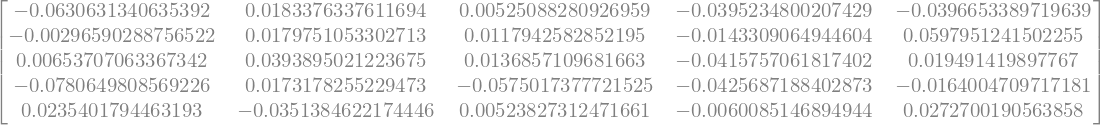

In [41]:
Ainv = AI_rref[0][:,5:];Ainv # extract the RHS block

Saya menulis sebuah fungsi untuk membulatkan angka desimal hingga $4$ digit, di bagian atas berkas ini, hanya untuk tujuan keterbacaan.


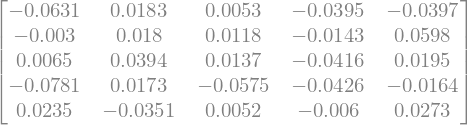

In [42]:
round_expr(Ainv, 4) 

We can verify if $AA^{-1}=\mathbf{I}$

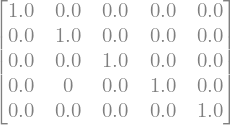

In [43]:
A = sy.Matrix(A)
round_expr(A*Ainv, 4) 

We got $\mathbf{I}$, which means the RHS block is indeed $A^{-1}$.

## <font face="gotham" color="purple"> Contoh Keberadaan Invers </font>


Tentukan nilai-nilai $\lambda$ sehingga matriks
$$
A=\begin{bmatrix}
3 & \lambda & 1 \\
2 & -1 & 6 \\
1 & 9 & 4
\end{bmatrix}
$$
tidak dapat diinvertkan.


Kita tetap menggunakan SymPy untuk menyelesaikan permasalahan ini.


In [44]:
lamb = sy.symbols('lamda') # SymPy will automatically render into LaTeX greek letters
A = np.array([[3, lamb, 1], [2, -1, 6], [1, 9, 4]])
I = np.eye(3); A

array([[3, lamda, 1],
       [2, -1, 6],
       [1, 9, 4]], dtype=object)

Bentuk matriks teraugmen.


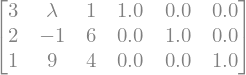

In [45]:
AI = np.hstack((A, I))
AI = sy.Matrix(AI); AI

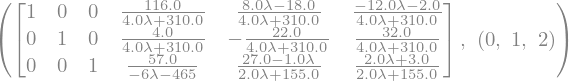

In [46]:
AI_rref = AI.rref()
AI_rref

Agar matriks $A$ dapat dibalik (invertible), kita perhatikan bahwa terdapat beberapa kondisi yang harus dipenuhi (pada penyebutnya):
$$
\begin{align*}
-6\lambda -465 &\neq 0\\
4\lambda + 310 &\neq 0\\
2\lambda + 155 &\neq 0
\end{align*}
$$

Namun, sebenarnya ketiganya merupakan satu kondisi saja, karena masing-masing merupakan kelipatan satu sama lain.


Selesaikan  ini $\lambda$'s.

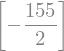

In [47]:
sy.solvers.solve(-6*lamb-465, lamb)

Jadi, ini adalah nilai $\lambda$ yang membuat matriks dapat dibalik (invertible).  
Mari kita uji menggunakan _determinan_. Jika $|A| = 0$, maka matriks tersebut tidak dapat dibalik.  
Selanjutnya, substitusikan nilai $\lambda$ kembali ke dalam $A$, lalu hitung determinannya.  
Jangan khawatir tentang determinan untuk saat ini; kita akan membahas topik ini lebih lanjut nanti.


In [48]:
A = np.array([[3, -155/2, 1], [2, -1, 6], [1, 9, 4]])
np.linalg.det(A)

Nilai $|A|$ adalah $0$.

Jadi, kita menemukan bahwa selama $\lambda \neq -\frac{155}{2}$, matriks $A$ dapat dibalik (invertible).


## <font face="gotham" color="purple"> Properties of Inverse Matrices </font>

1. Jika $A$ dan $B$ keduanya dapat dibalik (invertible), maka $(AB)^{-1} = B^{-1}A^{-1}$.
2. Jika $A$ dapat dibalik, maka $(A^T)^{-1} = (A^{-1})^T$.
3. Jika $A$ dan $B$ keduanya dapat dibalik dan simetris, serta memenuhi $AB = BA$, maka $A^{-1}B$ adalah matriks simetris.


_Sifat pertama_ cukup sederhana:
$$
\begin{align}
ABB^{-1}A^{-1} = AIA^{-1} = I = AB(AB)^{-1}
\end{align}
$$


Trik pada _sifat kedua_ adalah menunjukkan bahwa
$$
A^T(A^{-1})^T = I
$$
Kita dapat menggunakan sifat transpose:
$$
A^T(A^{-1})^T = (A^{-1}A)^T = I^T = I
$$


_Sifat ketiga_ adalah menunjukkan bahwa
$$
A^{-1}B = (A^{-1}B)^T
$$

Sekali lagi, kita gunakan sifat transpose:
$$
(A^{-1}B)^T = B^T(A^{-1})^T = B(A^T)^{-1} = BA^{-1}
$$

Kita gunakan kondisi $AB = BA$ untuk melanjutkan:
\begin{align*}
AB &= BA \\
A^{-1}ABA^{-1} &= A^{-1}BAA^{-1} \\
BA^{-1} &= A^{-1}B
\end{align*}

Kemudian substitusikan ke persamaan sebelumnya, kita peroleh:
$$
(A^{-1}B)^T = BA^{-1} = A^{-1}B
$$
